# ML Monitoring Case Study — Churn Model

## Detect data drift, score shifts, and delayed performance degradation

This self-contained case study uses reproducible synthetic data. Every major step produces a result table and chart. The numbers illustrate a workflow and are not claims about real people or businesses.

In [1]:
from pathlib import Path
import json, warnings, joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563eb", "#059669", "#f59e0b", "#dc2626", "#64748b"]
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.options.display.float_format = "{:,.3f}".format

from scipy.stats import ks_2samp
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mkdir -p failed for path C:\Users\jacob\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\jacob\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\jacob\AppData\Local\Temp\matplotlib-r6sei4am because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Define the monitoring contract

Monitoring links every alert to an owner and an action.

,layer,signals,owner,response
0,System,Latency and failures,Platform,Immediate
1,Data,"Schema, missingness, drift",Data engineering,Investigate source
2,Predictions,Score distribution and positive rate,ML engineering,Compare versions
3,Outcomes,"PR AUC, ROC AUC, calibration",Data science,Champion/challenger


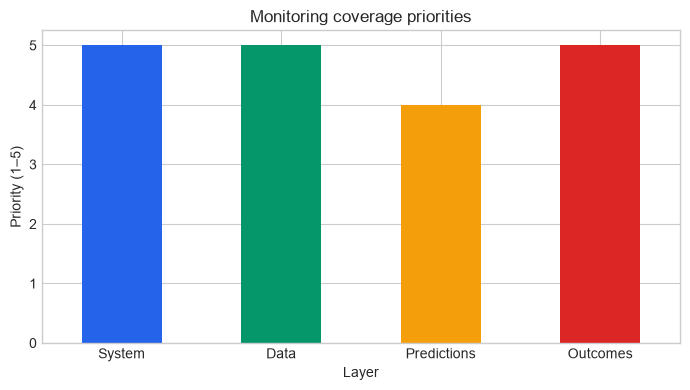

In [2]:
contract=pd.DataFrame([("System","Latency and failures","Platform","Immediate"),("Data","Schema, missingness, drift","Data engineering","Investigate source"),("Predictions","Score distribution and positive rate","ML engineering","Compare versions"),("Outcomes","PR AUC, ROC AUC, calibration","Data science","Champion/challenger")],columns=["layer","signals","owner","response"])
display(contract); ax=pd.Series({"System":5,"Data":5,"Predictions":4,"Outcomes":5}).plot.bar(color=COLORS[:4],rot=0,figsize=(7,4)); ax.set(title="Monitoring coverage priorities",ylabel="Priority (1–5)",xlabel="Layer"); plt.tight_layout(); plt.show()

## 2. Create baseline and shifted synthetic populations

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,churned
0,3.017,1.723,2.187,-0.206,0.531,0.943,0
1,3.766,0.129,1.098,-3.528,1.208,-0.813,0
2,-2.104,3.038,-0.750,-0.751,0.317,2.388,0
3,1.675,-1.347,2.082,2.670,-1.429,-0.944,1
4,1.798,-0.108,-2.994,-4.265,1.361,-0.403,0
5,-2.186,-1.007,-1.684,-1.580,0.849,-0.614,0
6,0.261,2.460,2.208,-1.467,1.328,-0.756,0
7,1.581,-3.972,3.110,-1.052,1.226,0.102,1


,mean,std,missing_n
feature_0,0.279,1.803,0
feature_1,0.897,1.544,0
feature_2,0.004,1.625,0
feature_3,-0.888,1.546,0
feature_4,0.885,1.351,0
feature_5,-0.000,1.004,0


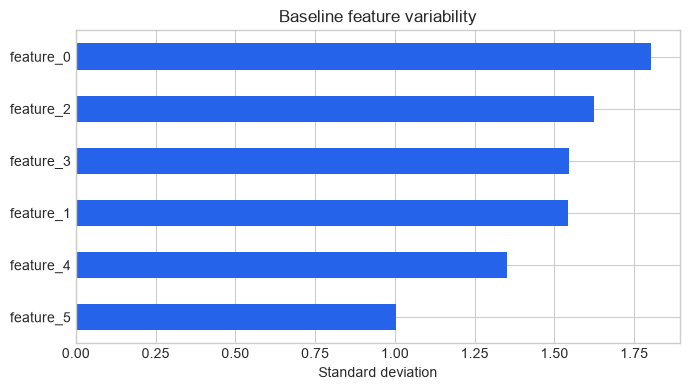

In [3]:
X,y=make_classification(n_samples=9000,n_features=6,n_informative=5,n_redundant=0,weights=[.78,.22],class_sep=1.15,random_state=RANDOM_STATE)
features=[f"feature_{i}" for i in range(X.shape[1])]; base=pd.DataFrame(X,columns=features); base["churned"]=y
quality=pd.DataFrame({"mean":base[features].mean(),"std":base[features].std(),"missing_n":base[features].isna().sum()})
display(base.head(8)); display(quality)
ax=quality["std"].sort_values().plot.barh(color=COLORS[0],figsize=(7,4)); ax.set(title="Baseline feature variability",xlabel="Standard deviation",ylabel=""); plt.tight_layout(); plt.show()

## 3. Train and record the launch baseline

,value
rows,"2,700.000"
churn_rate,0.223
mean_score,0.396
roc_auc,0.858
average_precision,0.627


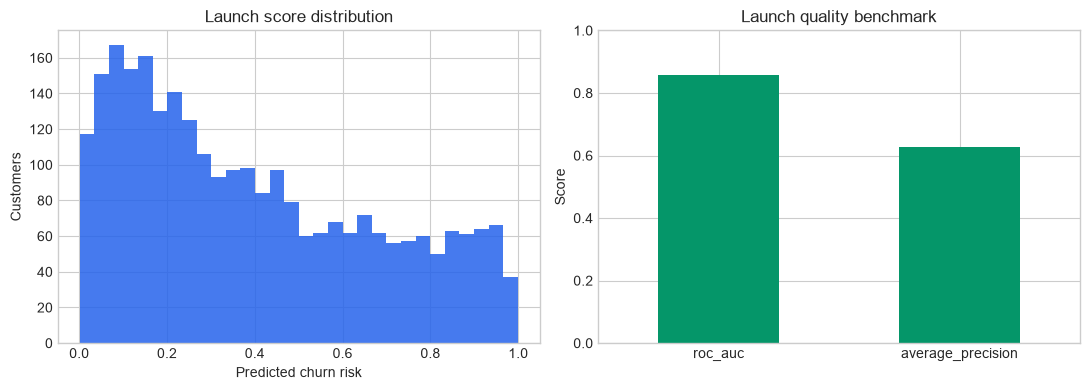

In [4]:
X_train,X_hold,y_train,y_hold=train_test_split(base[features],base.churned,test_size=.3,stratify=base.churned,random_state=RANDOM_STATE)
model=Pipeline([("scale",StandardScaler()),("model",LogisticRegression(max_iter=1500,class_weight="balanced"))]).fit(X_train,y_train)
base_score=model.predict_proba(X_hold)[:,1]
launch=pd.DataFrame({"value":{"rows":len(X_hold),"churn_rate":y_hold.mean(),"mean_score":base_score.mean(),"roc_auc":roc_auc_score(y_hold,base_score),"average_precision":average_precision_score(y_hold,base_score)}})
display(launch)
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].hist(base_score,bins=30,color=COLORS[0],alpha=.85); axes[0].set(title="Launch score distribution",xlabel="Predicted churn risk",ylabel="Customers")
launch.loc[["roc_auc","average_precision"]].plot.bar(ax=axes[1],legend=False,color=COLORS[1],rot=0); axes[1].set(title="Launch quality benchmark",ylabel="Score",xlabel="",ylim=(0,1)); plt.tight_layout(); plt.show()

## 4. Simulate weekly production drift

,week,missingness_pct,mean_score,positive_rate
0,1,1.000,0.399,0.350
1,2,1.000,0.410,0.360
2,3,1.000,0.397,0.340
3,4,1.000,0.406,0.347
4,5,1.000,0.371,0.299
5,6,1.000,0.407,0.353
6,7,1.000,0.388,0.336
7,8,1.000,0.392,0.329
8,9,2.200,0.413,0.366
9,10,3.400,0.403,0.334


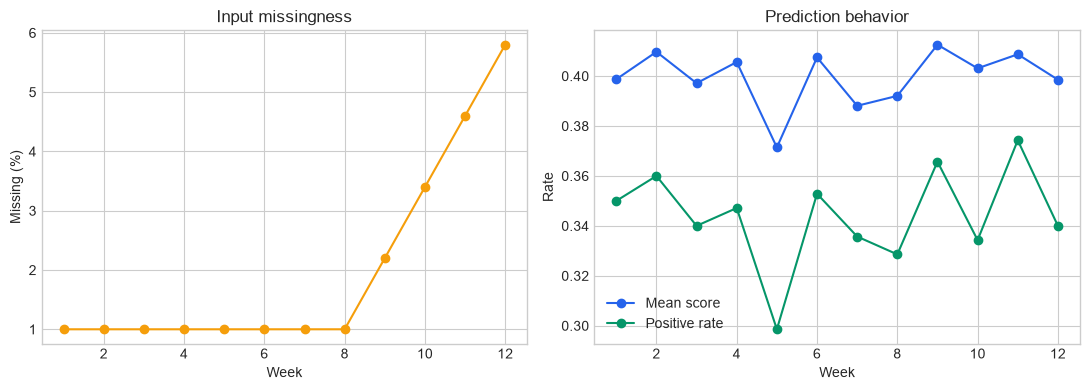

In [5]:
weekly=[]; weekly_frames=[]
for week in range(1,13):
    sample=base.sample(700,replace=True,random_state=100+week).reset_index(drop=True)
    strength=max(0,week-7)*.12
    sample["feature_0"]+=strength; sample["feature_3"]-=strength*.7
    miss=min(.01+max(0,week-8)*.012,.08); sample.loc[rng.choice(len(sample),int(len(sample)*miss),replace=False),"feature_2"]=np.nan
    scoring=sample[features].fillna(X_train.median()); score=model.predict_proba(scoring)[:,1]
    weekly_frames.append((week,sample,score)); weekly.append((week,miss*100,score.mean(),(score>=.5).mean()))
weekly_table=pd.DataFrame(weekly,columns=["week","missingness_pct","mean_score","positive_rate"])
display(weekly_table)
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].plot(weekly_table.week,weekly_table.missingness_pct,marker="o",color=COLORS[2]); axes[0].set(title="Input missingness",xlabel="Week",ylabel="Missing (%)")
axes[1].plot(weekly_table.week,weekly_table.mean_score,marker="o",label="Mean score",color=COLORS[0]); axes[1].plot(weekly_table.week,weekly_table.positive_rate,marker="o",label="Positive rate",color=COLORS[1]); axes[1].set(title="Prediction behavior",xlabel="Week",ylabel="Rate"); axes[1].legend(); plt.tight_layout(); plt.show()

## 5. Quantify feature drift with KS statistics

,week,feature,ks_stat,p_value
66,12,feature_0,0.126,0.000
60,11,feature_0,0.119,0.000
54,10,feature_0,0.108,0.000
69,12,feature_3,0.094,0.000
63,11,feature_3,0.086,0.001
57,10,feature_3,0.078,0.002
48,9,feature_0,0.077,0.003
24,5,feature_0,0.059,0.041
70,12,feature_4,0.057,0.051
10,2,feature_4,0.057,0.054


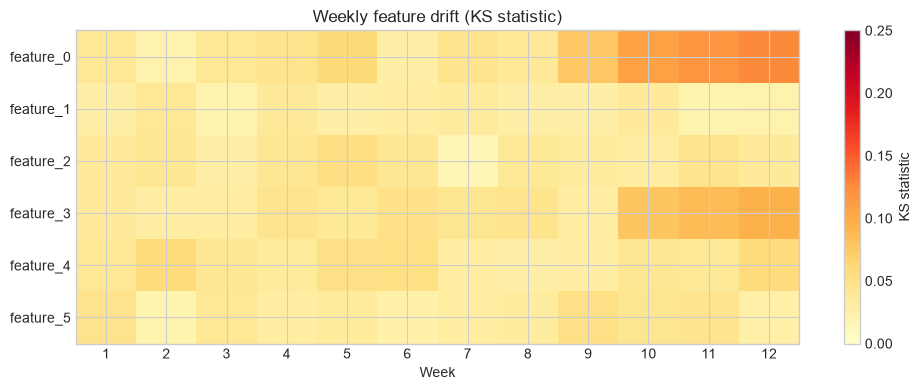

In [6]:
drift=[]
for week,sample,score in weekly_frames:
    for f in features:
        stat,p=ks_2samp(X_hold[f],sample[f].dropna()); drift.append((week,f,stat,p))
drift_table=pd.DataFrame(drift,columns=["week","feature","ks_stat","p_value"]); drift_pivot=drift_table.pivot(index="week",columns="feature",values="ks_stat")
display(drift_table.sort_values("ks_stat",ascending=False).head(20))
fig,ax=plt.subplots(figsize=(10,4)); im=ax.imshow(drift_pivot.T,aspect="auto",cmap="YlOrRd",vmin=0,vmax=max(.25,drift_pivot.max().max())); ax.set(xticks=range(12),xticklabels=range(1,13),yticks=range(len(features)),yticklabels=features,title="Weekly feature drift (KS statistic)",xlabel="Week"); plt.colorbar(im,ax=ax,label="KS statistic"); plt.tight_layout(); plt.show()

## 6. Track delayed model performance and alert status

,week,roc_auc,average_precision,actual_rate,alert
0,1,0.859,0.625,0.220,OK
1,2,0.855,0.597,0.210,OK
2,3,0.877,0.694,0.239,OK
3,4,0.830,0.628,0.247,OK
4,5,0.827,0.596,0.216,OK
5,6,0.851,0.609,0.223,OK
6,7,0.847,0.593,0.214,OK
7,8,0.848,0.598,0.214,OK
8,9,0.879,0.674,0.240,OK
9,10,0.827,0.634,0.217,OK


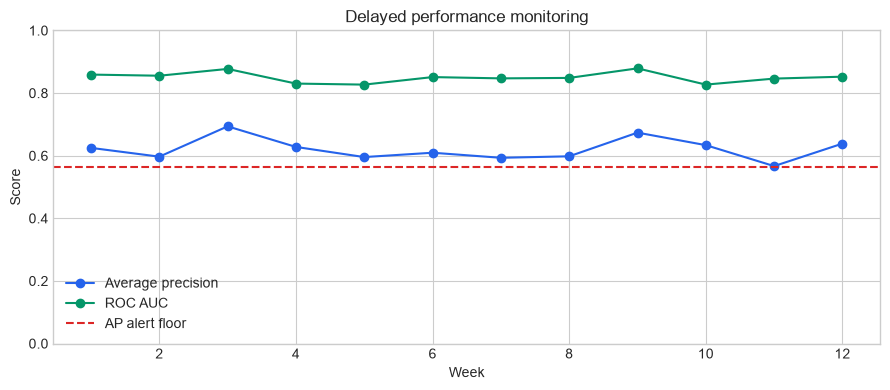

In [7]:
perf=[]
for week,sample,score in weekly_frames:
    # Labels are available here for demonstration; production labels often arrive later.
    perf.append((week,roc_auc_score(sample.churned,score),average_precision_score(sample.churned,score),sample.churned.mean()))
performance=pd.DataFrame(perf,columns=["week","roc_auc","average_precision","actual_rate"])
ap_floor=.90*launch.loc["average_precision","value"]; performance["alert"]=(performance.average_precision<ap_floor).map({True:"Investigate",False:"OK"})
display(performance)
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(performance.week,performance.average_precision,marker="o",label="Average precision",color=COLORS[0]); ax.plot(performance.week,performance.roc_auc,marker="o",label="ROC AUC",color=COLORS[1]); ax.axhline(ap_floor,color=COLORS[3],ls="--",label="AP alert floor"); ax.set(title="Delayed performance monitoring",xlabel="Week",ylabel="Score",ylim=(0,1)); ax.legend(); plt.tight_layout(); plt.show()

## 7. Build an alert dashboard and response runbook

,week,missingness_pct,mean_score,positive_rate,roc_auc,average_precision,actual_rate,alert,max_feature_ks,status
0,1,1.000,0.399,0.350,0.859,0.625,0.220,OK,0.046,GREEN
1,2,1.000,0.410,0.360,0.855,0.597,0.210,OK,0.057,GREEN
2,3,1.000,0.397,0.340,0.877,0.694,0.239,OK,0.040,GREEN
3,4,1.000,0.406,0.347,0.830,0.628,0.247,OK,0.046,GREEN
4,5,1.000,0.371,0.299,0.827,0.596,0.216,OK,0.059,GREEN
5,6,1.000,0.407,0.353,0.851,0.609,0.223,OK,0.051,GREEN
6,7,1.000,0.388,0.336,0.847,0.593,0.214,OK,0.046,GREEN
7,8,1.000,0.392,0.329,0.848,0.598,0.214,OK,0.046,GREEN
8,9,2.200,0.413,0.366,0.879,0.674,0.240,OK,0.077,GREEN
9,10,3.400,0.403,0.334,0.827,0.634,0.217,OK,0.108,GREEN


,status,action
0,GREEN,Continue scoring; record metrics
1,AMBER: drift,Check source changes and slice behavior
2,AMBER: quality,Validate upstream schema and imputation
3,RED: performance,Freeze rollout; compare champion/challenger


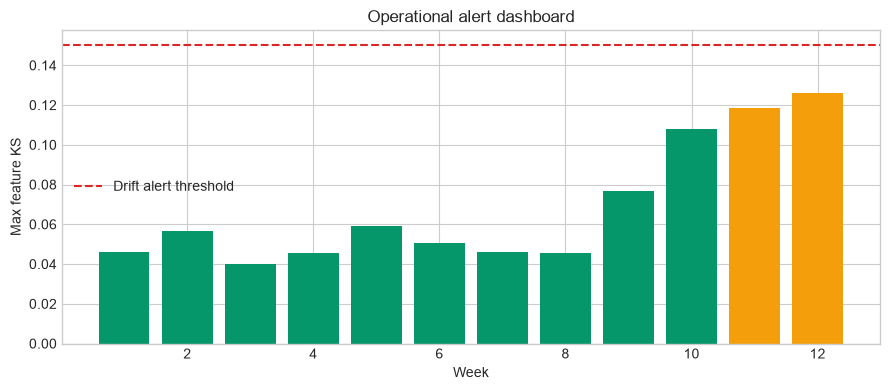

['monitoring_artifacts\\monitored_model.joblib']

In [8]:
dashboard=weekly_table.merge(performance,on="week"); dashboard["max_feature_ks"]=drift_pivot.max(axis=1).to_numpy(); dashboard["status"]=np.select([dashboard.average_precision<ap_floor,dashboard.max_feature_ks>.15,dashboard.missingness_pct>4],["RED: performance","AMBER: drift","AMBER: quality"],default="GREEN")
runbook=pd.DataFrame([("GREEN","Continue scoring; record metrics"),("AMBER: drift","Check source changes and slice behavior"),("AMBER: quality","Validate upstream schema and imputation"),("RED: performance","Freeze rollout; compare champion/challenger")],columns=["status","action"])
display(dashboard); display(runbook)
colors=dashboard.status.map({"GREEN":COLORS[1],"AMBER: drift":COLORS[2],"AMBER: quality":COLORS[2],"RED: performance":COLORS[3]})
fig,ax=plt.subplots(figsize=(9,4)); ax.bar(dashboard.week,dashboard.max_feature_ks,color=colors); ax.axhline(.15,color=COLORS[3],ls="--",label="Drift alert threshold"); ax.set(title="Operational alert dashboard",xlabel="Week",ylabel="Max feature KS"); ax.legend(); plt.tight_layout(); plt.show()
artifact_dir=Path("monitoring_artifacts"); artifact_dir.mkdir(exist_ok=True); dashboard.to_csv(artifact_dir/"monitoring_dashboard.csv",index=False); joblib.dump(model,artifact_dir/"monitored_model.joblib")

## Conclusion

Drift is a diagnostic, not proof of failure. A useful monitoring system combines service health, data quality, prediction behavior, delayed outcomes, owners, thresholds, and response playbooks.